# ROI Crossnobis RSA — group results

Crossnobis RDMs over the 8 stimulus identities from GLMsingle type-D cue betas, produced by
`run_rsa_roi.py`. Masks: whole brain, visual cortex, fusiform, vmPFC, striatum,
habit (Guida 2022), putamen (AAL), premotor (HMAT), parietal (AAL).

The question: *are stimuli with similar objective value represented more similarly?* Unlike
the high/low classifier, this makes a prediction identity and category cannot mimic — the
three pairs of stimuli that **share** a reward level should be extra-similar despite being
different images in different categories.

Prerequisites, both already run:
[`rsa_design_checks.ipynb`](rsa_design_checks.ipynb) (what the design allows) ·
[`crossnobis_validation.ipynb`](crossnobis_validation.ipynb) (that the distance is correct)

## Reading the numbers

Established in [`rsa_design_checks.ipynb`](rsa_design_checks.ipynb) (n=62):

- **`subset='nonfigure'` is primary.** Values {1,5} always sit on `figure` (62/62), so the
  all-8 version cannot separate extreme value from figure-vs-rest.
- **The "frequency" regressor is *choice* frequency, not presentation frequency.** Every
  stimulus is shown equally often (§1b: first-stim counts identical at 84 per stimulus for
  the ±1 label, zero variance); the label encodes how often the subject *chose* the
  stimulus, manipulated via pairing with higher-/lower-valued alternatives. `model='ck'`
  swaps the categorical label for the graded choice-kernel H-value (`|ΔH|`) in the same
  regressor slot — see §8a.
- **Value stays in the model** — corr(value, choice-frequency) = −0.346, fixed for everyone.
- **The same-value contrast is conservative**: those pairs carry the maximal |Δfreq|.

Conventions:

- Model RDMs are *dis*similarity predictions → **positive β = represented**.
- `contrast_value` = mean(diff-value) − mean(same-value) → **positive = value coding**.
- β are standardised partial weights (RDM and predictors z-scored), comparable across
  subjects and ROIs. Tested against 0, which crossnobis's unbiasedness licenses.
- No identity regressor: every off-diagonal cell is different-identity, so identity *is*
  the intercept.

**Status:** run 2026-08-27, n=58 (`participants_mvpa.tsv` minus `sub-46`); rerun same day
with the `ck` model variant. See Findings at the bottom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests

DERIV_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives")
RSA_DIR = DERIV_DIR / "rsa"
RSA_SHUFFLED_DIR = DERIV_DIR / "rsa_shuffled"   # negative control; may be absent

MASKS = ["wholebrain", "visualcortex", "fusiform", "vmpfc", "striatum",
         "habit", "putamen", "premotor", "parietal"]
MASK_LABELS = {"wholebrain": "Whole brain", "visualcortex": "Visual cortex",
               "fusiform": "Fusiform", "vmpfc": "vmPFC", "striatum": "Striatum",
               "habit": "Habit (Guida)", "putamen": "Putamen", "premotor": "Premotor",
               "parietal": "Parietal"}
COLORS = {"wholebrain": "#4C72B0", "visualcortex": "#DD8452", "fusiform": "#937860",
          "vmpfc": "#55A868", "striatum": "#C44E52",
          "habit": "#8172B3", "putamen": "#CCB974", "premotor": "#64B5CD",
          "parietal": "#8C8C8C"}

SCOPES = ["pooled", "learning1", "learning2", "test"]
RUN_SCOPES = ["learning1", "learning2", "test"]

# The 3 terms of interest + 2 confound-control regressors.
# second_stim_value: |Δ(mean value of the paired alternative)| per first-stim identity.
# choice_rate: |Δ(P(chose first stim))| — captures decision/motor confounds.
MODEL_TERMS = ["category", "value", "frequency", "second_stim_value", "choice_rate"]
TERMS_OF_INTEREST = ["category", "value", "frequency"]   # plotted in main bar charts
TERM_COLORS = {"category": "#8172B3", "value": "#C44E52", "frequency": "#64B5CD",
               "second_stim_value": "#CCB974", "choice_rate": "#8C8C8C"}

# Primary readouts. 'nonfigure' is the counterbalanced test (values {1,5} always sit on
# the figure category, so the all-8 version cannot separate extreme value from
# figure-vs-rest); 'objective' is the fixed reward level, 'rl' the model-derived Q.
# 'frequency' throughout is CHOICE frequency (equal presentations; manipulated via
# pairing) -- 'ck' swaps the categorical +-1 label for the graded choice-kernel |dH|
# in that same regressor slot (see SS8a).
PRIMARY_SUBSET = "nonfigure"
PRIMARY_MODEL = "objective"

In [2]:
def load_results(rsa_dir):
    """Concatenate every subject's long-format RSA results CSV."""
    files = sorted(Path(rsa_dir).glob("sub-*/sub-*_rsa_results.csv"))
    if not files:
        return pd.DataFrame()
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


def load_rdms(rsa_dir, mask, scope):
    """{subject: 8x8 crossnobis RDM} for one mask/scope, rows ordered as stim_names."""
    out = {}
    for f in sorted(Path(rsa_dir).glob(f"sub-*/sub-*_rsa_rdm_{mask}_{scope}.npy")):
        out[f.parent.name] = np.load(f)
    return out


def load_model_rdms(rsa_dir):
    """{subject: npz} of per-subject model RDMs and per-stimulus properties."""
    out = {}
    for f in sorted(Path(rsa_dir).glob("sub-*/sub-*_rsa_model_rdms.npz")):
        out[f.parent.name] = np.load(f, allow_pickle=True)
    return out


def group_test(values):
    """One-sample t-test and Wilcoxon against 0, plus mean/sem. Valid against 0 because
    crossnobis distances are unbiased under the null, so the regression coefficients are
    too (no need for a permutation reference for the location test)."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) < 3:
        return dict(n=len(v), mean=np.nan, sem=np.nan, t=np.nan, p=np.nan, p_wilcoxon=np.nan)
    t, p = stats.ttest_1samp(v, 0)
    try:
        _, pw = stats.wilcoxon(v)
    except ValueError:
        pw = np.nan
    return dict(n=len(v), mean=v.mean(), sem=v.std(ddof=1) / np.sqrt(len(v)),
                t=float(t), p=float(p), p_wilcoxon=float(pw))


def summarise(df, column, scope="pooled", subset=PRIMARY_SUBSET, model=PRIMARY_MODEL):
    """Group test of `column` per mask, for one (scope, subset, model) slice."""
    sel = df[(df.scope == scope) & (df["subset"] == subset) & (df.model == model)]
    rows = []
    for mask in MASKS:
        vals = sel.loc[sel["mask"] == mask, column].values
        rows.append(dict(mask=mask, **group_test(vals)))
    return pd.DataFrame(rows).set_index("mask")


def stars(p):
    if not np.isfinite(p):
        return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""


df = load_results(RSA_DIR)
df_shuf = load_results(RSA_SHUFFLED_DIR)
model_rdms = load_model_rdms(RSA_DIR)

print(f"real:     {df.subject.nunique() if len(df) else 0} subjects, {len(df)} rows")
print(f"shuffled: {df_shuf.subject.nunique() if len(df_shuf) else 0} subjects")
if len(df):
    print("scopes:", sorted(df.scope.unique()), "| subsets:", sorted(df['subset'].unique()),
          "| models:", sorted(df.model.unique()))
    print("within-run split:", df.within_run_split.unique())
    print("\nvoxels per mask (median):")
    print(df.groupby("mask").n_voxels.median().reindex(MASKS).to_string())

real:     58 subjects, 12528 rows
shuffled: 58 subjects
scopes: ['learning1', 'learning2', 'pooled', 'test'] | subsets: ['all', 'nonfigure'] | models: ['ck', 'objective', 'rl']
within-run split: ['interleaved']

voxels per mask (median):
mask
wholebrain      64620.0
visualcortex     7600.0
fusiform          320.0
vmpfc             119.0
striatum          128.0
habit             657.0
putamen           500.0
premotor         4334.0
parietal         2866.0


## 1. Model RDMs

Re-derived from the saved npz files, i.e. from the data actually processed. Should match
`rsa_design_checks.ipynb`.

In [3]:
# Re-derive the design facts from the processed data rather than trusting the docstring.
iu = np.triu_indices(8, 1)
rows, assignments = [], set()
for sub, npz in model_rdms.items():
    cat, val, frq = npz["category"], npz["value"], npz["frequency"]
    c, v, f = cat[iu], val[iu], frq[iu]
    nf = npz["non_figure"]
    names, values = npz["stim_names"], npz["stim_value"]
    assignments.add(tuple(zip(map(str, names), values.astype(int))))
    same_v, cross = v == 0, c > 0
    rows.append(dict(
        subject=sub,
        r_cat_val=np.corrcoef(c, v)[0, 1], r_cat_frq=np.corrcoef(c, f)[0, 1],
        r_val_frq=np.corrcoef(v, f)[0, 1],
        n_nonfigure=int(nf.sum()), n_same_value=int(same_v.sum()),
        same_value_all_cross=bool(cross[same_v].all()),
        dfrq_same_value=f[same_v].mean(), dfrq_diff_value=f[~same_v & cross].mean(),
        extreme_cat="/".join(sorted(set(np.asarray(npz["stim_cat"])[np.isin(values, [1, 5])]))),
    ))
mr = pd.DataFrame(rows)

print(f"distinct image->value assignments across {len(mr)} subjects: {len(assignments)}")
print(f"category holding values {{1,5}}: {mr.extreme_cat.value_counts().to_dict()}")
print(f"all same-value pairs cross-category: {mr.same_value_all_cross.all()}")
print(f"\nmodel RDM intercorrelations (min .. max across subjects):")
for c in ["r_cat_val", "r_cat_frq", "r_val_frq"]:
    print(f"  {c:11s} {mr[c].min():+.3f} .. {mr[c].max():+.3f}")
print(f"\nmean |dfreq| on same-value pairs   : {mr.dfrq_same_value.mean():.3f}")
print(f"mean |dfreq| on diff-value x-cat   : {mr.dfrq_diff_value.mean():.3f}"
      "   <- frequency runs AGAINST the value hypothesis in contrast_value")

distinct image->value assignments across 58 subjects: 12
category holding values {1,5}: {'figure': 58}
all same-value pairs cross-category: True

model RDM intercorrelations (min .. max across subjects):
  r_cat_val   -0.179 .. -0.179
  r_cat_frq   -0.232 .. +0.310
  r_val_frq   -0.346 .. -0.346

mean |dfreq| on same-value pairs   : 2.000
mean |dfreq| on diff-value x-cat   : 0.995   <- frequency runs AGAINST the value hypothesis in contrast_value


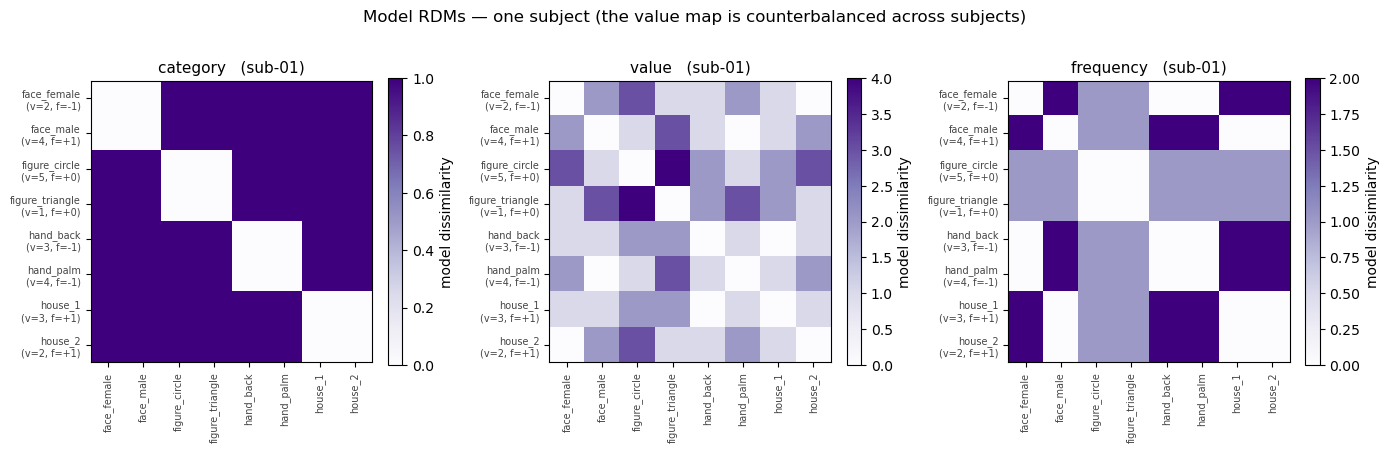

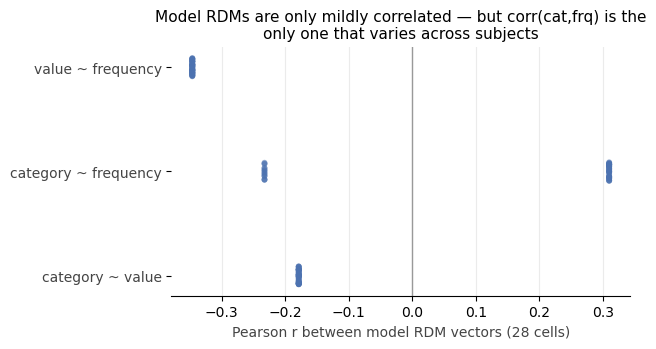

In [4]:
# One example subject's model RDMs. Non-negative dissimilarity predictions -> sequential
# single-hue map (see the signed crossnobis RDMs below for why those differ).
ex_sub = sorted(model_rdms)[0]
npz = model_rdms[ex_sub]
labels = [f"{n}\n(v={int(v)}, f={int(f):+d})" for n, v, f
          in zip(npz["stim_names"], npz["stim_value"], npz["stim_frequency"])]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, term in zip(axes, MODEL_TERMS):
    m = npz[term]
    im = ax.imshow(m, cmap="Purples", vmin=0)
    ax.set_title(f"{term}   ({ex_sub})", fontsize=11)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.set_xticklabels(npz["stim_names"], rotation=90, fontsize=7, color="#444444")
    ax.set_yticklabels(labels, fontsize=7, color="#444444")
    fig.colorbar(im, ax=ax, fraction=0.046, label="model dissimilarity")
fig.suptitle("Model RDMs — one subject (the value map is counterbalanced across subjects)",
             fontsize=12)
fig.tight_layout()
plt.show()

# Intercorrelation spread across subjects. corr(cat,val) and corr(val,frq) are fixed by
# the design; corr(cat,frq) is the only one that varies, which is what lets the
# regression separate the category and frequency terms at the group level.
fig, ax = plt.subplots(figsize=(6.5, 3.6))
pairs = [("r_cat_val", "category ~ value"), ("r_cat_frq", "category ~ frequency"),
         ("r_val_frq", "value ~ frequency")]
for i, (col, lab) in enumerate(pairs):
    ax.scatter(mr[col], np.full(len(mr), i) + np.random.uniform(-.09, .09, len(mr)),
               s=18, color="#4C72B0", alpha=.55, edgecolor="none", zorder=3)
ax.axvline(0, color="#999999", linewidth=1, zorder=1)
ax.set_yticks(range(len(pairs))); ax.set_yticklabels([p[1] for p in pairs], color="#444444")
ax.set_xlabel("Pearson r between model RDM vectors (28 cells)", color="#444444")
ax.set_title("Model RDMs are only mildly correlated — but corr(cat,frq) is the\n"
             "only one that varies across subjects", fontsize=11)
ax.grid(axis="x", alpha=.25, zorder=0); ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

### 1b. Model matrix condition number and VIF

With 5 regressors (category, value, frequency, second_stim_value, choice_rate) fit on
only 15 upper-triangle cells (non-figure subset), multicollinearity could destabilise
partial coefficients. Compute the condition number (κ) and variance inflation factors
per subject on the actual z-scored model matrix.

In [5]:
# §1b — Condition number and VIF of the 5-predictor model matrix
# The regression fits 15 upper-triangle cells (6 non-figure stimuli) on 5 z-scored
# model RDMs + intercept.  Category and frequency RDMs are fixed across subjects;
# value, second_stim_value, and choice_rate vary (objective model shown here; rl/ck
# swap only one term and produce similar collinearity).

def _z(v):
    v = np.asarray(v, dtype=float)
    s = v.std()
    return (v - v.mean()) / s if s > 0 else v - v.mean()

def _triu(m):
    return m[np.triu_indices(m.shape[0], k=1)]

def vif_from_X(X):
    """VIF for each column of a design matrix (no intercept column expected)."""
    from numpy.linalg import lstsq
    p = X.shape[1]
    vifs = np.empty(p)
    for j in range(p):
        y_j = X[:, j]
        X_rest = np.delete(X, j, axis=1)
        X_aug = np.column_stack([np.ones(len(y_j)), X_rest])
        coef, *_ = lstsq(X_aug, y_j, rcond=None)
        y_hat = X_aug @ coef
        ss_res = ((y_j - y_hat) ** 2).sum()
        ss_tot = ((y_j - y_j.mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        vifs[j] = 1 / (1 - r2) if r2 < 1 else np.inf
    return vifs

scope = "pooled"
non_fig = None
rows_vif = []
for sub_id, npz in model_rdms.items():
    if non_fig is None:
        non_fig = npz["non_figure"]
    keep = non_fig
    cat_rdm = npz["category"]
    val_rdm = npz["value"]           # objective value (fixed by design)
    freq_rdm = npz["frequency"]
    s2v_rdm = npz[f"s2v_{scope}"]
    cr_rdm = npz[f"cr_{scope}"]

    sub_idx = np.ix_(keep, keep)
    cols = []
    for rdm in [cat_rdm, val_rdm, freq_rdm, s2v_rdm, cr_rdm]:
        v = _triu(rdm[sub_idx])
        cols.append(_z(v))
    X = np.column_stack(cols)

    kappa = np.linalg.cond(X)
    vifs = vif_from_X(X)
    rows_vif.append({"subject": sub_id, "cond_number": kappa,
                     **{f"VIF_{t}": v for t, v in zip(MODEL_TERMS, vifs)}})

vif_df = pd.DataFrame(rows_vif).set_index("subject").sort_index()

print(f"Model matrix diagnostics (scope={scope}, subset=nonfigure, model=objective)")
print(f"  n_subjects = {len(vif_df)}")
print(f"  n_pairs (upper-tri cells) = {len(_triu(cat_rdm[sub_idx]))}")
print(f"  n_predictors = {len(MODEL_TERMS)}")
print()
print("Condition number κ(X):")
print(f"  median = {vif_df.cond_number.median():.1f}")
print(f"  max    = {vif_df.cond_number.max():.1f}")
print(f"  subjects with κ > 30: {(vif_df.cond_number > 30).sum()}")
print()
vif_cols = [c for c in vif_df.columns if c.startswith("VIF_")]
print("VIF per predictor (median [min–max] across subjects):")
for c in vif_cols:
    term = c.replace("VIF_", "")
    lo, med, hi = vif_df[c].min(), vif_df[c].median(), vif_df[c].max()
    flag = " ⚠️" if med > 5 else ""
    print(f"  {term:20s}  {med:.2f}  [{lo:.2f} – {hi:.2f}]{flag}")
print()
print("Rule of thumb: κ < 30 and VIF < 5–10 are acceptable.")

Model matrix diagnostics (scope=pooled, subset=nonfigure, model=objective)
  n_subjects = 58
  n_pairs (upper-tri cells) = 15
  n_predictors = 5

Condition number κ(X):
  median = 2.7
  max    = 4.1
  subjects with κ > 30: 0

VIF per predictor (median [min–max] across subjects):
  category              1.24  [1.11 – 1.97]
  value                 1.92  [1.34 – 4.35]
  frequency             1.24  [1.17 – 1.84]
  second_stim_value     1.98  [1.29 – 3.57]
  choice_rate           1.46  [1.10 – 2.39]

Rule of thumb: κ < 30 and VIF < 5–10 are acceptable.


## 2. Group RDMs

Two views, because subjects have different image → value mappings:

- **image space** — structure here is visual (category/identity); value is scrambled by the
  counterbalancing. Sanity check: category blocks should show in visual cortex.
- **value space** — each subject's RDM reordered by *their* stimulus values before
  averaging. Value structure survives this; idiosyncratic image similarity doesn't.

Crossnobis is signed, so the maps are diverging with a neutral midpoint at 0.

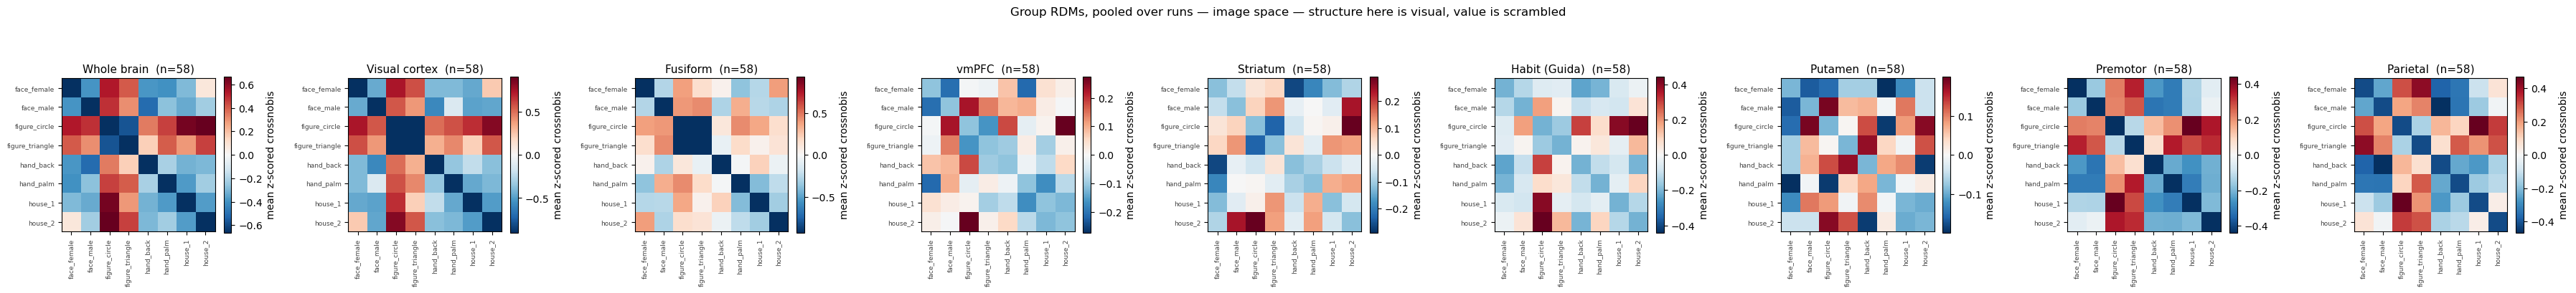

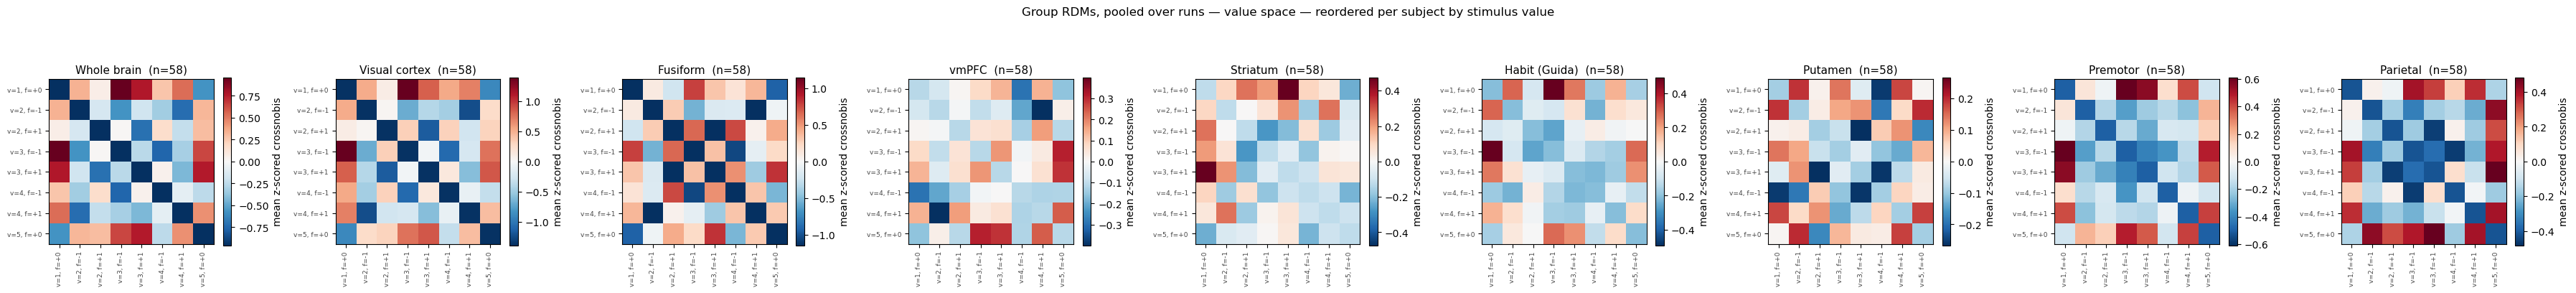

In [6]:
def _z_rdm(r):
    v = r[iu]
    return (r - v.mean()) / v.std() if v.std() > 0 else r - v.mean()


def group_rdm(mask, scope="pooled", space="image"):
    """Mean z-scored RDM across subjects, in image space or value space.

    Each subject's RDM is z-scored over its off-diagonal cells first so that subjects
    with globally larger distances do not dominate the average.
    """
    mats = load_rdms(RSA_DIR, mask, scope)
    stacked, order_labels = [], None
    for sub, r in mats.items():
        npz = model_rdms[sub]
        if space == "image":
            idx = np.argsort(npz["stim_names"])
            labs = [str(s) for s in npz["stim_names"][idx]]
        elif space == "value":
            # sort by (value, frequency) so every subject's rows line up by value
            idx = np.lexsort((npz["stim_frequency"], npz["stim_value"]))
            labs = [f"v={int(v)}, f={int(f):+d}" for v, f in
                    zip(npz["stim_value"][idx], npz["stim_frequency"][idx])]
        else:
            raise ValueError(space)
        if order_labels is None:
            order_labels = labs
        elif space == "value" and labs != order_labels:
            raise ValueError(f"{sub}: value ordering differs from the first subject — "
                             f"{labs} vs {order_labels}")
        stacked.append(_z_rdm(r)[np.ix_(idx, idx)])
    if not stacked:
        return None, None, 0
    return np.mean(stacked, axis=0), order_labels, len(stacked)


for space, blurb in [("image", "image space — structure here is visual, value is scrambled"),
                     ("value", "value space — reordered per subject by stimulus value")]:
    fig, axes = plt.subplots(1, len(MASKS), figsize=(4 * len(MASKS), 4.3))
    for ax, mask in zip(np.atleast_1d(axes), MASKS):
        g, labs, n = group_rdm(mask, "pooled", space)
        if g is None:
            ax.set_visible(False)
            continue
        lim = np.abs(g[iu]).max()
        im = ax.imshow(g, cmap="RdBu_r", vmin=-lim, vmax=lim)   # diverging, 0 = neutral
        ax.set_title(f"{MASK_LABELS[mask]}  (n={n})", fontsize=11)
        ax.set_xticks(range(8)); ax.set_yticks(range(8))
        ax.set_xticklabels(labs, rotation=90, fontsize=6.5, color="#444444")
        ax.set_yticklabels(labs, fontsize=6.5, color="#444444")
        fig.colorbar(im, ax=ax, fraction=0.046, label="mean z-scored crossnobis")
    fig.suptitle(f"Group RDMs, pooled over runs — {blurb}", fontsize=12)
    fig.tight_layout()
    plt.show()


subset = 'nonfigure'   scope = 'pooled'   model = 'objective'   (n = 58)
mask                        category                 value             frequency     second_stim_value           choice_rate
Whole brain          +0.035±0.043          -0.038±0.053          +0.203±0.038***       +0.084±0.055          -0.023±0.051   
Visual cortex        +0.036±0.045          -0.080±0.034*         +0.337±0.031***       +0.060±0.041          -0.120±0.043** 
Fusiform             +0.037±0.045          -0.118±0.033***       +0.373±0.034***       +0.159±0.040***       -0.049±0.043   
vmPFC                +0.014±0.034          -0.122±0.048*         -0.041±0.030          +0.035±0.058          -0.019±0.040   
Striatum             +0.042±0.028          +0.076±0.046          +0.091±0.035*         -0.059±0.054          +0.069±0.050   
Habit (Guida)        +0.060±0.035          +0.018±0.049          +0.055±0.032          +0.054±0.059          +0.078±0.051   
Putamen              +0.053±0.036          +0.024±0

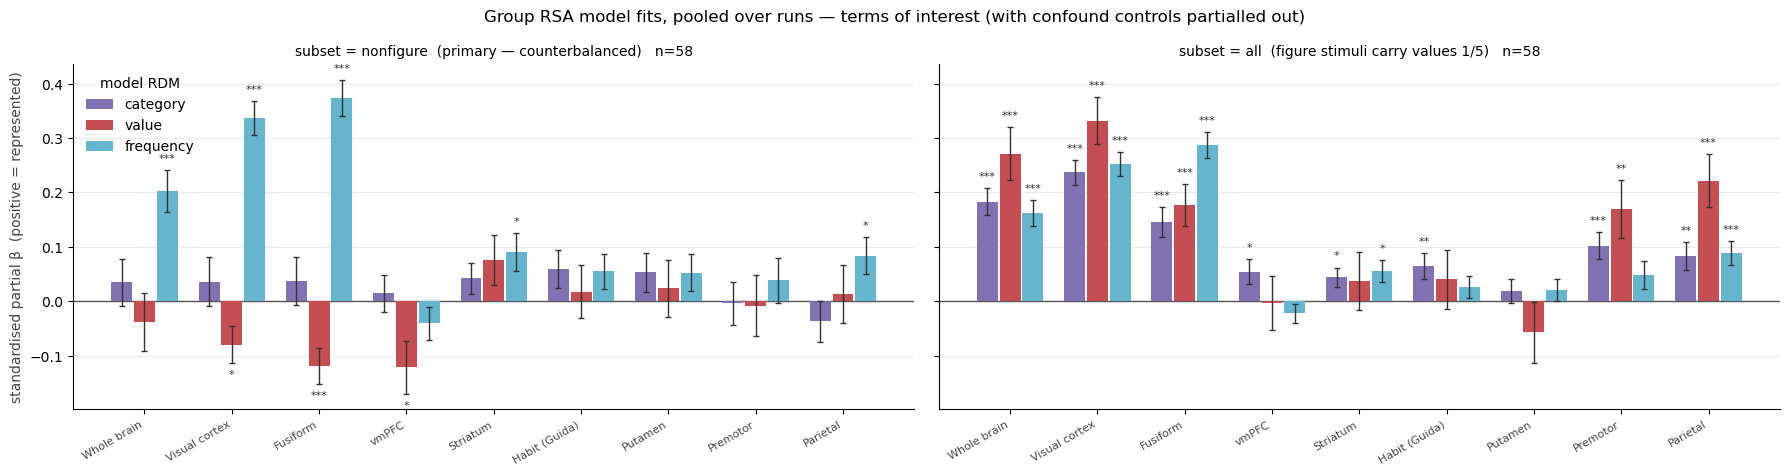

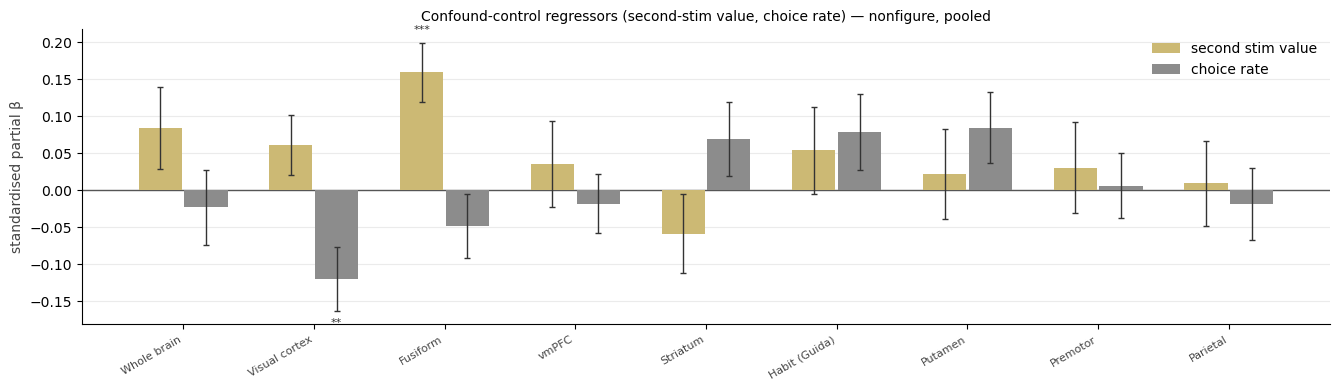

In [7]:
def beta_table(subset, model=PRIMARY_MODEL, scope="pooled", frame=None, terms=None):
    frame = df if frame is None else frame
    terms = MODEL_TERMS if terms is None else terms
    out = {}
    for term in terms:
        col = f"beta_{term}"
        if col not in frame.columns:
            continue
        s = summarise(frame, col, scope=scope, subset=subset, model=model)
        out[term] = s
    return out


for subset in ["nonfigure", "all"]:
    tabs = beta_table(subset)
    available = [t for t in MODEL_TERMS if t in tabs]
    print(f"\n{'='*100}\nsubset = {subset!r}   scope = 'pooled'   model = {PRIMARY_MODEL!r}"
          f"   (n = {tabs[available[0]]['n'].max():.0f})\n{'='*100}")
    print(f"{'mask':14s}" + "".join(f"{t:>22s}" for t in available))
    for mask in MASKS:
        cells = []
        for term in available:
            r = tabs[term].loc[mask]
            cells.append(f"{r['mean']:+.3f}±{r['sem']:.3f}{stars(r['p']):<3s}")
        print(f"{MASK_LABELS[mask]:14s}" + "".join(f"{c:>22s}" for c in cells))

# --- Main bar chart: terms of interest (cat/val/freq) ---
fig, axes = plt.subplots(1, 2, figsize=(max(13, 2 * len(MASKS)), 4.8), sharey=True)
for ax, subset in zip(axes, ["nonfigure", "all"]):
    tabs = beta_table(subset, terms=TERMS_OF_INTEREST)
    avail = [t for t in TERMS_OF_INTEREST if t in tabs]
    x = np.arange(len(MASKS)); w = 0.26
    for j, term in enumerate(avail):
        s = tabs[term].reindex(MASKS)
        off = (j - 1) * w
        ax.bar(x + off, s["mean"], width=w - 0.02, color=TERM_COLORS[term],
               label=term if ax is axes[0] else None, zorder=3)
        ax.errorbar(x + off, s["mean"], yerr=s["sem"], fmt="none", color="#333333",
                    capsize=2.5, linewidth=1, zorder=4)
        for xi, (m, p) in enumerate(zip(s["mean"], s["p"])):
            if stars(p):
                ax.text(xi + off, m + np.sign(m) * (s["sem"].iloc[xi] + .012), stars(p),
                        ha="center", va="bottom" if m >= 0 else "top",
                        fontsize=8, color="#333333")
    ax.axhline(0, color="#555555", linewidth=1, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=30,
                                         ha="right", fontsize=8, color="#444444")
    n = int(tabs[avail[0]]["n"].max())
    ax.set_title(f"subset = {subset}"
                 f"{'  (primary — counterbalanced)' if subset=='nonfigure' else '  (figure stimuli carry values 1/5)'}"
                 f"   n={n}", fontsize=10)
    ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
axes[0].set_ylabel("standardised partial β  (positive = represented)", color="#444444")
axes[0].legend(frameon=False, loc="upper left", title="model RDM")
fig.suptitle("Group RSA model fits, pooled over runs — terms of interest (with confound controls partialled out)",
             fontsize=12)
fig.tight_layout()
plt.show()

# --- Confound-control regressors ---
CONFOUND_TERMS = ["second_stim_value", "choice_rate"]
confound_tabs = beta_table("nonfigure", terms=CONFOUND_TERMS)
avail_c = [t for t in CONFOUND_TERMS if t in confound_tabs]
if avail_c:
    fig, ax = plt.subplots(figsize=(max(9, 1.5 * len(MASKS)), 4))
    x = np.arange(len(MASKS)); w = 0.35
    for j, term in enumerate(avail_c):
        s = confound_tabs[term].reindex(MASKS)
        off = (j - 0.5) * w
        ax.bar(x + off, s["mean"], width=w - 0.02, color=TERM_COLORS[term],
               label=term.replace("_", " "), zorder=3)
        ax.errorbar(x + off, s["mean"], yerr=s["sem"], fmt="none", color="#333333",
                    capsize=2.5, linewidth=1, zorder=4)
        for xi, (m, p) in enumerate(zip(s["mean"], s["p"])):
            if stars(p):
                ax.text(xi + off, m + np.sign(m) * (s["sem"].iloc[xi] + .01), stars(p),
                        ha="center", va="bottom" if m >= 0 else "top",
                        fontsize=8, color="#333333")
    ax.axhline(0, color="#555555", linewidth=1, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=30,
                                         ha="right", fontsize=8, color="#444444")
    ax.set_ylabel("standardised partial β", color="#444444")
    ax.set_title("Confound-control regressors (second-stim value, choice rate) — nonfigure, pooled",
                 fontsize=10)
    ax.legend(frameon=False, loc="best")
    ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print("Confound-control columns not yet in data — rerun with updated run_rsa_roi.py.")

## 3a. FDR correction across the full test table

Benjamini-Hochberg applied to all ROI × term tests from the pooled/nonfigure/objective
slice. This is the minimum correction a reviewer would expect — it covers the primary
readout table only, not the per-run or model-variant extensions.

In [8]:
# Collect all p-values from the primary readout table (pooled, nonfigure, objective)
# across all ROIs and all MODEL_TERMS, then apply FDR.
fdr_rows = []
tabs_fdr = beta_table("nonfigure")
available_terms = [t for t in MODEL_TERMS if t in tabs_fdr]
for term in available_terms:
    s = tabs_fdr[term].reindex(MASKS)
    for mask in MASKS:
        fdr_rows.append(dict(mask=mask, term=term, p=s.loc[mask, "p"],
                             mean=s.loc[mask, "mean"], sem=s.loc[mask, "sem"]))

# Also include the same-value contrast
con_fdr = summarise(df, "contrast_value", scope="pooled", subset=PRIMARY_SUBSET)
for mask in MASKS:
    fdr_rows.append(dict(mask=mask, term="contrast_value", p=con_fdr.loc[mask, "p"],
                         mean=con_fdr.loc[mask, "mean"], sem=con_fdr.loc[mask, "sem"]))

fdr_df = pd.DataFrame(fdr_rows)
reject, pvals_corr, _, _ = multipletests(fdr_df["p"].values, alpha=0.05, method="fdr_bh")
fdr_df["p_fdr"] = pvals_corr
fdr_df["sig_fdr"] = reject

print(f"FDR correction (Benjamini-Hochberg) across {len(fdr_df)} tests "
      f"({len(MASKS)} ROIs × {len(available_terms)} terms + contrast)")
print(f"{'mask':14s}{'term':>20s}{'β':>8s}{'p_unc':>10s}{'p_fdr':>10s}{'sig':>5s}")
for _, r in fdr_df.sort_values(["term", "mask"]).iterrows():
    print(f"{MASK_LABELS[r['mask']]:14s}{r['term']:>20s}{r['mean']:>+8.3f}"
          f"{r['p']:>10.4f}{r['p_fdr']:>10.4f}{'  *' if r['sig_fdr'] else ''}")

n_sig_unc = (fdr_df.p < 0.05).sum()
n_sig_fdr = fdr_df.sig_fdr.sum()
print(f"\n{n_sig_unc} tests significant uncorrected, {n_sig_fdr} survive FDR at q=0.05")

FDR correction (Benjamini-Hochberg) across 54 tests (9 ROIs × 5 terms + contrast)
mask                          term       β     p_unc     p_fdr  sig
Fusiform                  category  +0.037    0.4096    0.6703
Habit (Guida)             category  +0.060    0.0931    0.3142
Parietal                  category  -0.037    0.3260    0.6288
Premotor                  category  -0.004    0.9194    0.9194
Putamen                   category  +0.053    0.1389    0.3324
Striatum                  category  +0.042    0.1388    0.3324
Visual cortex             category  +0.036    0.4216    0.6703
vmPFC                     category  +0.014    0.6755    0.8082
Whole brain               category  +0.035    0.4198    0.6703
Fusiform               choice_rate  -0.049    0.2589    0.5377
Habit (Guida)          choice_rate  +0.078    0.1331    0.3324
Parietal               choice_rate  -0.019    0.6968    0.8082
Premotor               choice_rate  +0.006    0.8997    0.9167
Putamen                choice_r

## 4. The targeted contrast

Among pairs that are all different-identity and all different-category: are those sharing a
reward level more similar? This is the readout that most directly escapes the identity
confound. Only 3 same-value cells per subject, so the group test is the only meaningful
level.

contrast_value — pooled, subset='nonfigure'  (positive = value coding)

mask             n     mean     sem       t         p   p(wilcox)
Whole brain     58   -0.202   0.077   -2.62    0.0112*     0.0094
Visual cortex   58   -0.519   0.055   -9.45    0.0000***   0.0000
Fusiform        58   -0.637   0.052  -12.29    0.0000***   0.0000
vmPFC           58   -0.062   0.076   -0.81    0.4220      0.5030
Striatum        58   +0.034   0.065    0.53    0.6005      0.6395
Habit (Guida)   58   -0.027   0.066   -0.41    0.6849      0.5693
Putamen         58   -0.060   0.084   -0.71    0.4790      0.2941
Premotor        58   -0.020   0.072   -0.28    0.7793      0.6121
Parietal        58   -0.033   0.070   -0.48    0.6325      0.6175


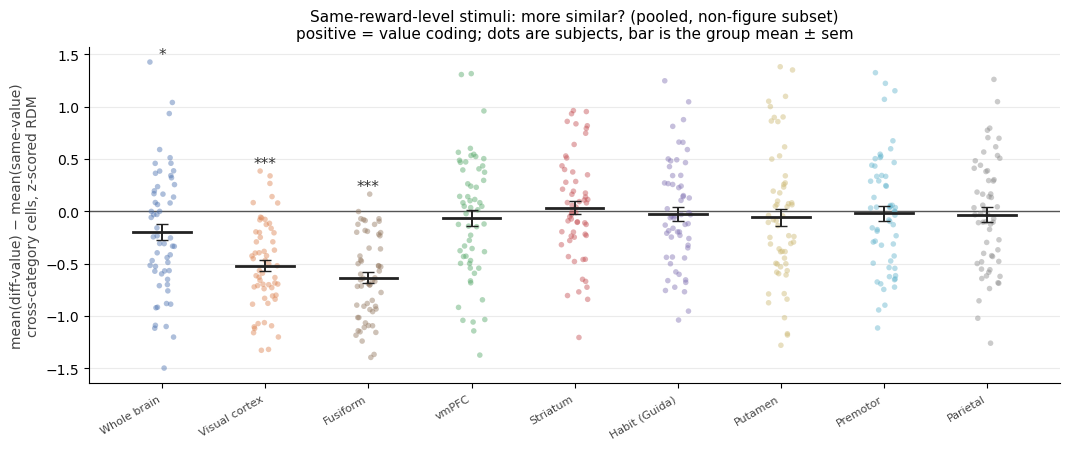

In [9]:
con = summarise(df, "contrast_value", scope="pooled", subset=PRIMARY_SUBSET)
print(f"contrast_value — pooled, subset={PRIMARY_SUBSET!r}  (positive = value coding)\n")
print(f"{'mask':14s}{'n':>4s}{'mean':>9s}{'sem':>8s}{'t':>8s}{'p':>10s}{'p(wilcox)':>12s}")
for mask in MASKS:
    r = con.loc[mask]
    print(f"{MASK_LABELS[mask]:14s}{r['n']:>4.0f}{r['mean']:>+9.3f}{r['sem']:>8.3f}"
          f"{r['t']:>8.2f}{r['p']:>10.4f}{stars(r['p']):<3s}{r['p_wilcoxon']:>9.4f}")

# Per-subject distribution behind each group mean — never show only the bar.
fig, ax = plt.subplots(figsize=(max(8.5, 1.2 * len(MASKS)), 4.6))
sel = df[(df.scope == "pooled") & (df["subset"] == PRIMARY_SUBSET) & (df.model == PRIMARY_MODEL)]
for i, mask in enumerate(MASKS):
    v = sel.loc[sel["mask"] == mask, "contrast_value"].dropna().values
    ax.scatter(np.full(len(v), i) + np.random.uniform(-.13, .13, len(v)), v,
               s=16, color=COLORS[mask], alpha=.45, edgecolor="none", zorder=3)
    r = con.loc[mask]
    ax.plot([i - .28, i + .28], [r["mean"]] * 2, color="#222222", linewidth=2, zorder=5)
    ax.errorbar(i, r["mean"], yerr=r["sem"], fmt="none", color="#222222",
                capsize=4, linewidth=1.4, zorder=5)
    if stars(r["p"]):
        ax.text(i, v.max() if len(v) else 0, stars(r["p"]), ha="center", va="bottom",
                fontsize=11, color="#333333")
ax.axhline(0, color="#555555", linewidth=1, zorder=2)
ax.set_xticks(range(len(MASKS)))
ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=30, ha="right",
                   fontsize=8, color="#444444")
ax.set_ylabel("mean(diff-value) − mean(same-value)\ncross-category cells, z-scored RDM",
              color="#444444")
ax.set_title("Same-reward-level stimuli: more similar? (pooled, non-figure subset)\n"
             "positive = value coding; dots are subjects, bar is the group mean ± sem",
             fontsize=11)
ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
plt.show()

## 5. Learning dynamics

Per-run RDMs (within-run 2-fold CV). Look for value structure rising learning1 → learning2,
and persisting into `test`, which has **no feedback** — persistence there is the habit-relevant
claim.

These rest on half the trials and 2 folds instead of 3, so they are much noisier than pooled.
`crossnobis_validation.ipynb` §4 shows the two split modes diverge badly at low SNR — treat a
marginal result here as provisional until it reproduces under `--within-run-split blocked`.


β(objective value)  —  subset='nonfigure'
mask                     learning1           learning2                test
Whole brain        -0.038±0.039        +0.004±0.049        +0.040±0.066   
Visual cortex      -0.088±0.038*       -0.081±0.048        +0.009±0.056   
Fusiform           -0.175±0.031***     -0.194±0.043***     +0.120±0.066   
vmPFC              -0.054±0.042        +0.057±0.049        -0.104±0.052*  
Striatum           -0.019±0.040        +0.070±0.051        +0.071±0.055   
Habit (Guida)      -0.031±0.038        +0.063±0.049        +0.004±0.070   
Putamen            +0.020±0.047        +0.064±0.044        -0.003±0.064   
Premotor           -0.048±0.044        +0.032±0.046        +0.037±0.063   
Parietal           +0.026±0.047        -0.013±0.046        +0.080±0.069   

β(RL Q-value)  —  subset='nonfigure'
mask                     learning1           learning2                test
Whole brain        -0.022±0.037        +0.003±0.049        +0.040±0.066   
Visual cortex      

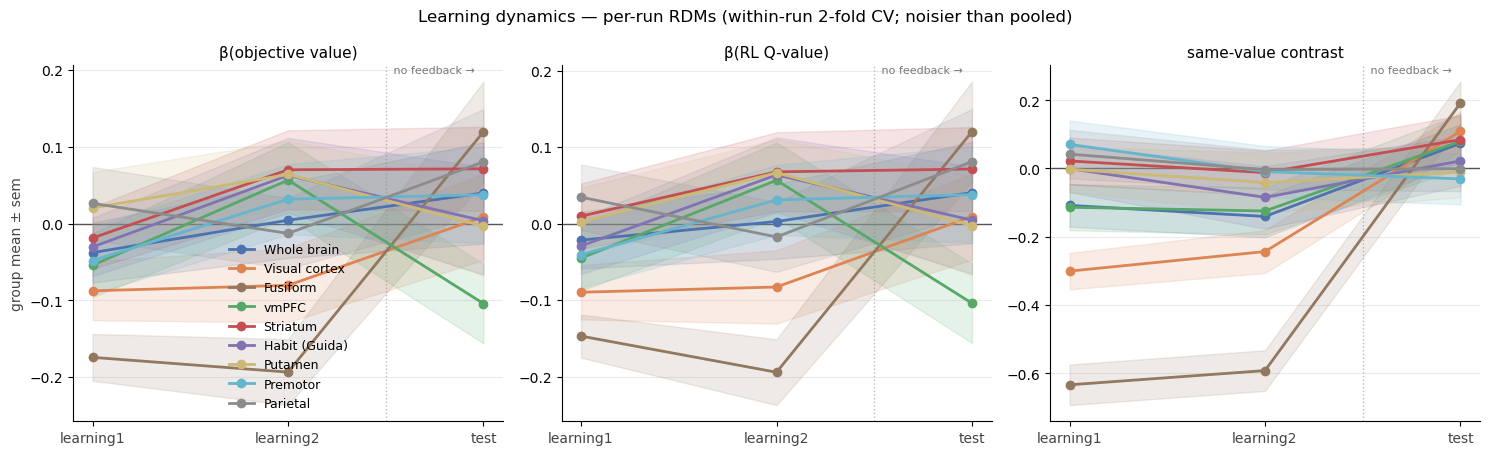

In [10]:
def dynamics(column, model=PRIMARY_MODEL, subset=PRIMARY_SUBSET):
    """(mask x run_scope) group mean/sem/p of `column`."""
    out = {}
    for mask in MASKS:
        out[mask] = {sc: group_test(
            df[(df.scope == sc) & (df["subset"] == subset) & (df.model == model) &
               (df["mask"] == mask)][column].values) for sc in RUN_SCOPES}
    return out


for column, model, title in [
        ("beta_value", "objective", "β(objective value)"),
        ("beta_value", "rl", "β(RL Q-value)"),
        ("contrast_value", "objective", "same-value contrast")]:
    d = dynamics(column, model=model)
    print(f"\n{title}  —  subset={PRIMARY_SUBSET!r}")
    print(f"{'mask':14s}" + "".join(f"{s:>20s}" for s in RUN_SCOPES))
    for mask in MASKS:
        cells = [f"{d[mask][s]['mean']:+.3f}±{d[mask][s]['sem']:.3f}{stars(d[mask][s]['p']):<3s}"
                 for s in RUN_SCOPES]
        print(f"{MASK_LABELS[mask]:14s}" + "".join(f"{c:>20s}" for c in cells))

# One line per ROI across the three runs. Color follows the ROI (the entity), not rank.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True)
panels = [("beta_value", "objective", "β(objective value)"),
          ("beta_value", "rl", "β(RL Q-value)"),
          ("contrast_value", "objective", "same-value contrast")]
x = np.arange(len(RUN_SCOPES))
for ax, (column, model, title) in zip(axes, panels):
    d = dynamics(column, model=model)
    for mask in MASKS:
        m = np.array([d[mask][s]["mean"] for s in RUN_SCOPES])
        e = np.array([d[mask][s]["sem"] for s in RUN_SCOPES])
        ax.plot(x, m, marker="o", markersize=6, linewidth=2, color=COLORS[mask],
                label=MASK_LABELS[mask] if ax is axes[0] else None, zorder=3)
        ax.fill_between(x, m - e, m + e, color=COLORS[mask], alpha=.15, zorder=2)
    ax.axhline(0, color="#555555", linewidth=1, zorder=1)
    ax.axvline(1.5, color="#BBBBBB", linewidth=1, linestyle=":", zorder=1)
    ax.text(1.52, ax.get_ylim()[1], " no feedback →", fontsize=8, color="#777777",
            va="top", ha="left")
    ax.set_xticks(x); ax.set_xticklabels(RUN_SCOPES, color="#444444")
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
axes[0].set_ylabel("group mean ± sem", color="#444444")
axes[0].legend(frameon=False, fontsize=9, loc="best")
fig.suptitle("Learning dynamics — per-run RDMs (within-run 2-fold CV; noisier than pooled)",
             fontsize=12)
fig.tight_layout()
plt.show()

## 6. Negative control — shuffled labels

End-to-end version of `crossnobis_validation.ipynb` §2, on real data. Everything should
collapse to ~0. Generate with:

```bash
SHUFFLE_SEED=1 OUTPUT_DIR=.../derivatives/rsa_shuffled bash multivariate/submit_rsa_roi.sh
```

Also checks `rdm_mean` straddles 0 under the shuffle (the unbiasedness property on real
data) and that the RDM diagonal is exactly 0.

real (n=58)  vs  shuffled (n=58)   pooled, subset='nonfigure'

mask          term                          real          shuffled
Whole brain   category               +0.035            -0.013     
Whole brain   value                  -0.038            -0.016     


Whole brain   frequency              +0.203***         -0.002     
Whole brain   second_stim_value       +0.084            +0.126*    
Whole brain   choice_rate            -0.023            +0.006     
Whole brain   contrast_value         -0.202*           -0.019     
Visual cortex category               +0.036            +0.049     
Visual cortex value                  -0.080*           -0.036     
Visual cortex frequency              +0.337***         -0.040     
Visual cortex second_stim_value       +0.060            +0.039     
Visual cortex choice_rate            -0.120**          +0.028     
Visual cortex contrast_value         -0.519***         -0.044     
Fusiform      category               +0.037            -0.010     
Fusiform      value                  -0.118***         -0.074*    
Fusiform      frequency              +0.373***         -0.022     
Fusiform      second_stim_value       +0.159***         +0.046     


Fusiform      choice_rate            -0.049            +0.056     
Fusiform      contrast_value         -0.637***         -0.204*    
vmPFC         category               +0.014            -0.015     


vmPFC         value                  -0.122*           +0.056     
vmPFC         frequency              -0.041            -0.014     
vmPFC         second_stim_value       +0.035            +0.067     
vmPFC         choice_rate            -0.019            -0.090     
vmPFC         contrast_value         -0.062            +0.067     
Striatum      category               +0.042            -0.015     
Striatum      value                  +0.076            +0.016     
Striatum      frequency              +0.091*           -0.028     
Striatum      second_stim_value       -0.059            +0.051     
Striatum      choice_rate            +0.069            +0.024     
Striatum      contrast_value         +0.034            -0.031     
Habit (Guida) category               +0.060            +0.009     
Habit (Guida) value                  +0.018            +0.020     
Habit (Guida) frequency              +0.055            +0.033     
Habit (Guida) second_stim_value       +0.054            +0.0

Habit (Guida) choice_rate            +0.078            +0.097     
Habit (Guida) contrast_value         -0.027            +0.008     
Putamen       category               +0.053            +0.018     


Putamen       value                  +0.024            +0.040     
Putamen       frequency              +0.052            +0.039     
Putamen       second_stim_value       +0.022            -0.034     
Putamen       choice_rate            +0.084            +0.078     
Putamen       contrast_value         -0.060            -0.007     
Premotor      category               -0.004            -0.023     
Premotor      value                  -0.008            +0.016     
Premotor      frequency              +0.038            -0.023     
Premotor      second_stim_value       +0.030            +0.090     
Premotor      choice_rate            +0.006            -0.016     
Premotor      contrast_value         -0.020            -0.034     
Parietal      category               -0.037            -0.012     
Parietal      value                  +0.014            -0.003     
Parietal      frequency              +0.083*           +0.013     
Parietal      second_stim_value       +0.009            +0.0

Parietal      contrast_value         -0.033            +0.011     


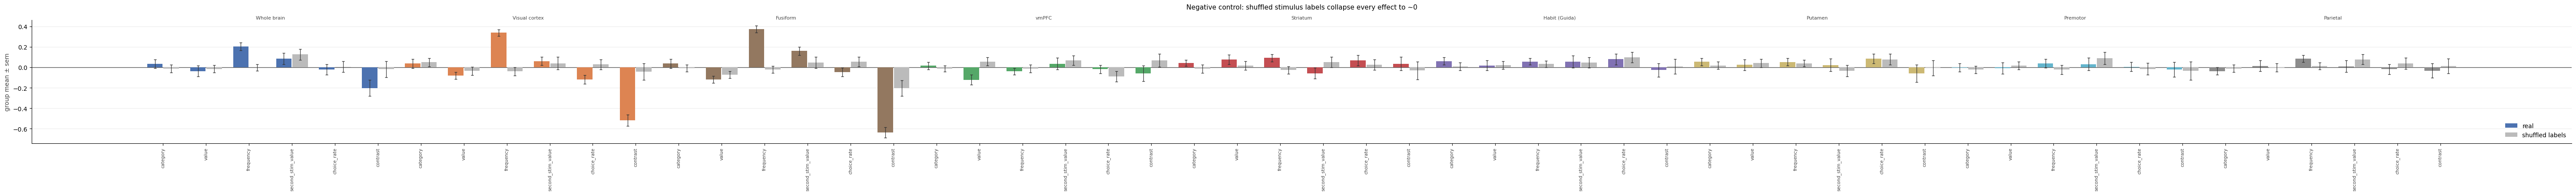


mean raw crossnobis distance (rdm_mean) — shuffled should straddle 0:
  Whole brain    real +0.00659   shuffled -0.00051
  Visual cortex  real +0.02768   shuffled -0.00055
  Fusiform       real +0.05207   shuffled -0.00101
  vmPFC          real +0.00293   shuffled -0.00023
  Striatum       real +0.00258   shuffled -0.00096
  Habit (Guida)  real +0.00191   shuffled -0.00059
  Putamen        real +0.00143   shuffled -0.00063
  Premotor       real +0.00464   shuffled -0.00037
  Parietal       real +0.00571   shuffled -0.00100

max |diagonal| over subjects (must be 0): 0.0


In [11]:
if not len(df_shuf):
    print(f"No shuffled control found at {RSA_SHUFFLED_DIR} — see the cell above to generate it.")
else:
    cols = [f"beta_{t}" for t in MODEL_TERMS] + ["contrast_value"]
    print(f"real (n={df.subject.nunique()})  vs  shuffled (n={df_shuf.subject.nunique()})"
          f"   pooled, subset={PRIMARY_SUBSET!r}\n")
    print(f"{'mask':14s}{'term':16s}{'real':>18s}{'shuffled':>18s}")
    for mask in MASKS:
        for c in cols:
            r = summarise(df, c, subset=PRIMARY_SUBSET).loc[mask]
            s = summarise(df_shuf, c, subset=PRIMARY_SUBSET).loc[mask]
            print(f"{MASK_LABELS[mask]:14s}{c.replace('beta_',''):16s}"
                  f"{r['mean']:>+13.3f}{stars(r['p']):<5s}"
                  f"{s['mean']:>+13.3f}{stars(s['p']):<5s}")

    fig, ax = plt.subplots(figsize=(max(9.5, 1.1 * len(MASKS) * len(cols)), 4.6))
    w = .38
    ticks, labs = [], []
    for i, mask in enumerate(MASKS):
        for j, c in enumerate(cols):
            k = i * len(cols) + j
            r = summarise(df, c, subset=PRIMARY_SUBSET).loc[mask]
            s = summarise(df_shuf, c, subset=PRIMARY_SUBSET).loc[mask]
            ax.bar(k - w/2, r["mean"], width=w - .02, color=COLORS[mask], zorder=3,
                   label="real" if k == 0 else None)
            ax.bar(k + w/2, s["mean"], width=w - .02, color="#BBBBBB", zorder=3,
                   label="shuffled labels" if k == 0 else None)
            ax.errorbar([k - w/2, k + w/2], [r["mean"], s["mean"]],
                        yerr=[r["sem"], s["sem"]], fmt="none", color="#333333",
                        capsize=2, linewidth=.9, zorder=4)
            ticks.append(k); labs.append(c.replace("beta_", "").replace("contrast_value", "contrast"))
    ax.axhline(0, color="#555555", linewidth=1, zorder=2)
    ax.set_xticks(ticks); ax.set_xticklabels(labs, rotation=90, fontsize=7.5, color="#444444")
    for i, mask in enumerate(MASKS):
        ax.text(i * len(cols) + (len(cols) - 1) / 2, ax.get_ylim()[1],
                MASK_LABELS[mask], ha="center", va="bottom", fontsize=8, color="#444444")
    ax.set_ylabel("group mean ± sem", color="#444444")
    ax.set_title("Negative control: shuffled stimulus labels collapse every effect to ~0",
                 fontsize=11, pad=18)
    ax.legend(frameon=False, loc="lower right")
    ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    fig.tight_layout()
    plt.show()

# Unbiasedness + diagonal checks
print("\nmean raw crossnobis distance (rdm_mean) — shuffled should straddle 0:")
for mask in MASKS:
    q = lambda f, m=mask: f[(f.scope == "pooled") & (f["subset"] == "all") &
                    (f.model == PRIMARY_MODEL) & (f["mask"] == m)].rdm_mean
    real_m = q(df).mean()
    shuf_m = q(df_shuf).mean() if len(df_shuf) else np.nan
    print(f"  {MASK_LABELS[mask]:14s} real {real_m:+.5f}   shuffled {shuf_m:+.5f}")

diags = [np.abs(np.diag(r)).max() for r in load_rdms(RSA_DIR, "visualcortex", "pooled").values()]
print(f"\nmax |diagonal| over subjects (must be 0): {max(diags) if diags else float('nan')}")

## 7. Robustness controls — amplitude confound and split mode

Two follow-up runs (jobs 5331516 / 5331517):

- **remove-mean** (`derivatives/rsa_remove_mean`): each trial pattern's spatial mean
  subtracted before crossnobis. Presentations are equal across the frequency label (§1b),
  so classic repetition suppression is not a candidate confound here — but a
  *choice-related* global-gain difference is (e.g. attention or motor preparation being
  stronger for frequently-chosen stimuli, scaling the whole response uniformly with no
  shared geometry). If that were driving the effect, it would collapse under remove-mean.
  The amplitude CSVs give the direct test too: amplitude ~ choice-frequency across stimuli.
- **blocked split** (`derivatives/rsa_blocked`): per-run RDMs re-estimated with
  first-half/second-half folds instead of interleaved. Any per-run result that doesn't
  reproduce across split modes is noise (`crossnobis_validation.ipynb` §4).

In [12]:
df_rm = load_results(DERIV_DIR / "rsa_remove_mean")
df_bl = load_results(DERIV_DIR / "rsa_blocked")

if not len(df_rm) or not len(df_bl):
    print("Control runs not found — see the cell above to generate them.")
else:
    # --- (a) does beta_frequency survive remove-mean? ------------------------
    print("=== (a) beta_frequency, pooled / nonfigure: original vs remove-mean ===")
    print(f"{'mask':14s}{'original':>16s}{'remove-mean':>16s}")
    for mask in MASKS:
        r = summarise(df, "beta_frequency").loc[mask]
        m = summarise(df_rm, "beta_frequency").loc[mask]
        print(f"{MASK_LABELS[mask]:14s}{r['mean']:>+13.3f}{stars(r['p']):<3s}"
              f"{m['mean']:>+13.3f}{stars(m['p']):<3s}")

    print("\nbeta_value and contrast_value under remove-mean:")
    for mask in MASKS:
        v = summarise(df_rm, "beta_value").loc[mask]
        c = summarise(df_rm, "contrast_value").loc[mask]
        print(f"{MASK_LABELS[mask]:14s} value {v['mean']:+.3f}{stars(v['p']):<3s}"
              f"   contrast {c['mean']:+.3f}{stars(c['p']):<3s}")

    # --- (a2) the direct amplitude ~ frequency test (adaptation signature) ----
    amp_files = sorted((DERIV_DIR / "rsa_remove_mean").glob("sub-*/sub-*_rsa_amplitude.csv"))
    amps = pd.concat([pd.read_csv(f).assign(subject=f.parent.name) for f in amp_files],
                     ignore_index=True)
    frq_map = {(s, str(n)): float(fq) for s, z in model_rdms.items()
               for n, fq in zip(z["stim_names"], z["stim_frequency"])}
    amps["frequ"] = [frq_map[(s, n)] for s, n in zip(amps.subject, amps.stim_name)]

    print("\n=== (a2) amplitude ~ frequency across stimuli (per-subject r, tested vs 0) ===")
    print(f"{'mask':14s}{'mean r':>10s}{'p':>10s}   high-minus-low amp (p)")
    for mask in MASKS:
        a = amps[amps["mask"] == mask]
        rs = a.groupby("subject").apply(
            lambda g: np.corrcoef(g.mean_amp, g.frequ)[0, 1], include_groups=False)
        t, p = stats.ttest_1samp(rs, 0)
        d = (a[a.frequ == 1].groupby("subject").mean_amp.mean()
             - a[a.frequ == -1].groupby("subject").mean_amp.mean())
        td, pd_ = stats.ttest_1samp(d, 0)
        print(f"{MASK_LABELS[mask]:14s}{rs.mean():>+10.3f}{p:>10.4f}   "
              f"{d.mean():+.4f} (p={pd_:.4f})")

    # --- (b) does the test-run sign flip reproduce under blocked split? -------
    print("\n=== (b) same-value contrast per run: interleaved vs blocked ===")
    print(f"{'mask':14s}" + "".join(f"{s:>14s}" for s in RUN_SCOPES) + "   |"
          + "".join(f"{s:>14s}" for s in RUN_SCOPES))
    print(f"{'':14s}{'-- interleaved --':>42s}   |{'-- blocked --':>42s}")
    for mask in MASKS:
        cells = []
        for frame in (df, df_bl):
            for sc in RUN_SCOPES:
                r = summarise(frame, "contrast_value", scope=sc).loc[mask]
                cells.append(f"{r['mean']:+.3f}{stars(r['p']):<3s}")
        print(f"{MASK_LABELS[mask]:14s}" + "".join(f"{c:>14s}" for c in cells[:3])
              + "   |" + "".join(f"{c:>14s}" for c in cells[3:]))

=== (a) beta_frequency, pooled / nonfigure: original vs remove-mean ===
mask                  original     remove-mean


Whole brain          +0.203***       +0.207***
Visual cortex        +0.337***       +0.375***
Fusiform             +0.373***       +0.420***
vmPFC                -0.041          -0.005   
Striatum             +0.091*         +0.093*  
Habit (Guida)        +0.055          +0.049   
Putamen              +0.052          +0.057   
Premotor             +0.038          +0.036   
Parietal             +0.083*         +0.071*  

beta_value and contrast_value under remove-mean:
Whole brain    value -0.035      contrast -0.198*  
Visual cortex  value -0.074*     contrast -0.570***
Fusiform       value -0.099**    contrast -0.675***
vmPFC          value -0.075      contrast -0.071   
Striatum       value +0.047      contrast -0.042   
Habit (Guida)  value +0.032      contrast +0.033   
Putamen        value +0.006      contrast -0.038   
Premotor       value -0.003      contrast +0.031   


Parietal       value +0.017      contrast -0.016   



=== (a2) amplitude ~ frequency across stimuli (per-subject r, tested vs 0) ===
mask              mean r         p   high-minus-low amp (p)
Whole brain       -0.000    0.9985   -0.0007 (p=0.5948)
Visual cortex     -0.066    0.0041   -0.0100 (p=0.0107)
Fusiform          +0.012    0.7714   +0.0012 (p=0.9077)
vmPFC             -0.023    0.4026   -0.0061 (p=0.3497)
Striatum          -0.063    0.0359   -0.0113 (p=0.0342)
Habit (Guida)     +0.022    0.4614   +0.0027 (p=0.5528)
Putamen           +0.006    0.8492   +0.0008 (p=0.8810)
Premotor          -0.002    0.9551   +0.0005 (p=0.8993)
Parietal          -0.028    0.3687   -0.0025 (p=0.5406)

=== (b) same-value contrast per run: interleaved vs blocked ===
mask               learning1     learning2          test   |     learning1     learning2          test
                                       -- interleaved --   |                             -- blocked --
Whole brain        -0.108        -0.141*       +0.074      |     -0.088        -0.149

Fusiform           -0.634***     -0.592***     +0.192**    |     -0.602***     -0.526***     +0.074   
vmPFC              -0.114        -0.125        +0.080      |     +0.014        -0.023        -0.009   


Striatum           +0.022        -0.012        +0.084      |     +0.098        -0.028        +0.023   
Habit (Guida)      -0.001        -0.085        +0.022      |     +0.066        +0.113        +0.141*  
Putamen            -0.002        -0.041        -0.010      |     +0.101        +0.025        +0.039   
Premotor           +0.070        -0.009        -0.031      |     +0.068        -0.033        -0.078   


Parietal           +0.042        -0.003        -0.001      |     -0.019        -0.060        -0.030   


## 8a. Does graded habit strength beat the design label?

The ±1 choice-frequency label is a coarse, categorical proxy for a continuous behavioural
quantity we already have per subject per run: the choice-kernel H-value
(`first_stim_value_ck`). `model='ck'` re-runs the regression with the **frequency slot**
replaced by `|ΔH|` instead of the design label — everything else (category, objective
value) unchanged.

**Outcome: inconclusive, not "the label wins."** `|ΔH|` gives a sign-flipped, worse-fitting
result (paired r-comparison strongly negative, p<0.0001 in wholebrain/visual/fusiform).
But a diagnostic below shows why this can't be read as evidence against habit-strength
coding: `|ΔH|` barely reconstructs the design label's own pairwise structure
(corr(|ΔH|, |Δlabel|) ≈ 0, highly variable across subjects) even though per-stimulus H
correlates positively with the label (r≈+0.32, separately verified). A per-subject
median-split "H-bin" (matching the label's 3-vs-3 group sizes) was tried as a fix and does
not help either — same weak reconstruction despite 67% item-level agreement with the true
label. The noise is relational, not a magnitude-scale problem binning could fix. Read this
section as "our present operationalisation of H is too noisy to use here," not as a result
about habit-strength coding itself.

In [13]:
# beta_frequency under model='objective' is the coefficient on the design label; under
# model='ck' the SAME column holds the coefficient on |dH| (fit_rdm_regression puts
# whichever RDM was passed into the 'frequency' slot -- see run_rsa_roi.py run_subject).
print("=== label (+-1) vs graded H (|dH|): beta on the frequency-slot regressor ===")
print(f"{'mask':14s}{'label':>16s}{'graded H':>16s}")
for mask in MASKS:
    lab = summarise(df, "beta_frequency", model="objective").loc[mask]
    hv = summarise(df, "beta_frequency", model="ck").loc[mask]
    print(f"{MASK_LABELS[mask]:14s}{lab['mean']:>+13.3f}{stars(lab['p']):<3s}"
          f"{hv['mean']:>+13.3f}{stars(hv['p']):<3s}")

# Paired comparison: for each subject/mask, does |dH| correlate with the neural RDM
# better than the label does? (r_frequency is the zero-order correlation, saved
# regardless of which RDM occupied that slot.)
sel_lab = df[(df.scope == "pooled") & (df["subset"] == PRIMARY_SUBSET) & (df.model == "objective")]
sel_ck  = df[(df.scope == "pooled") & (df["subset"] == PRIMARY_SUBSET) & (df.model == "ck")]
merged = sel_lab.merge(sel_ck, on=["subject", "mask"], suffixes=("_label", "_ck"))

print("\n=== paired test: r(neural RDM, |dH|) - r(neural RDM, label), per subject ===")
for mask in MASKS:
    m = merged[merged["mask"] == mask]
    diff = m.r_frequency_ck - m.r_frequency_label
    t, p = stats.ttest_1samp(diff, 0)
    print(f"{MASK_LABELS[mask]:14s} mean diff = {diff.mean():+.3f}{stars(p):<3s}  "
          f"(p={p:.4f}, n={len(diff)})")

# DIAGNOSTIC, not a headline number: before trusting either direction, check whether
# |dH| even reconstructs the design label's own pairwise structure. If it doesn't, a
# sign-flipped or attenuated beta on |dH| says more about H being a noisy proxy than
# about the underlying construct.
print("\n=== diagnostic: does |dH| reconstruct the label's pairwise structure at all? ===")
iu6 = None
rs_recon = []
for sub, npz in model_rdms.items():
    idx = np.flatnonzero(npz["non_figure"])
    if iu6 is None:
        iu6 = np.triu_indices(len(idx), 1)
    lab = npz["stim_frequency"][idx].astype(float)
    H = npz["ck_value_pooled"][np.ix_(idx, idx)][iu6]
    dlab = np.abs(lab[:, None] - lab[None, :])[iu6]
    if H.std() > 0 and dlab.std() > 0:
        rs_recon.append(np.corrcoef(H, dlab)[0, 1])
rs_recon = np.array(rs_recon)
print(f"corr(|dH|, |dlabel|) across subjects: mean r = {rs_recon.mean():+.3f}, "
      f"range {rs_recon.min():+.3f} .. {rs_recon.max():+.3f}  (n={len(rs_recon)})")
print(">>> near-zero and highly variable: |dH| is a poor pairwise-distance proxy for the")
print(">>> design label, even though per-stimulus H correlates positively with the label")
print(">>> (checked separately, r~+0.32). The model='ck' comparison above should NOT be")
print(">>> read as evidence against habit-strength coding -- it reflects proxy noise.")

# Checked whether a per-subject median-split "H-bin" (matching the label's own 3-vs-3
# group sizes) reconstructs the label any better than continuous |dH| -- it does not
# (median-split |d(bin)| vs label: mean r ~ -0.09, same as continuous |dH|, despite the
# bin itself agreeing with the true label on ~67% of individual stimuli). The noise is
# relational (which PAIRS end up same/different), not a magnitude/scale artifact that
# binning would fix -- so binning was tried and does not rescue this comparison.

=== label (+-1) vs graded H (|dH|): beta on the frequency-slot regressor ===
mask                     label        graded H
Whole brain          +0.203***       -0.206** 
Visual cortex        +0.337***       -0.300***
Fusiform             +0.373***       -0.320***
vmPFC                -0.041          -0.025   


Striatum             +0.091*         +0.047   
Habit (Guida)        +0.055          +0.039   
Putamen              +0.052          -0.014   
Premotor             +0.038          -0.099   
Parietal             +0.083*         -0.058   

=== paired test: r(neural RDM, |dH|) - r(neural RDM, label), per subject ===
Whole brain    mean diff = -0.322***  (p=0.0000, n=58)
Visual cortex  mean diff = -0.579***  (p=0.0000, n=58)
Fusiform       mean diff = -0.588***  (p=0.0000, n=58)
vmPFC          mean diff = +0.008     (p=0.8547, n=58)
Striatum       mean diff = -0.008     (p=0.8694, n=58)
Habit (Guida)  mean diff = +0.050     (p=0.2959, n=58)
Putamen        mean diff = +0.027     (p=0.5601, n=58)
Premotor       mean diff = -0.080     (p=0.1075, n=58)
Parietal       mean diff = -0.118**   (p=0.0082, n=58)

=== diagnostic: does |dH| reconstruct the label's pairwise structure at all? ===
corr(|dH|, |dlabel|) across subjects: mean r = -0.089, range -0.217 .. +0.350  (n=58)
>>> near-zero and highly

In [14]:
# Two numbers referenced in the §8a markdown above (per-stimulus H~label correlation,
# and whether a median-split "H-bin" reconstructs the label better than continuous |dH|)
# were originally computed in scratch checks outside this notebook. Rescued here as
# executable code, restricted to the same 58-subject sample used everywhere above.
BBT_PATH = "/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bbt.csv"
bbt_ck = pd.read_csv(BBT_PATH, usecols=["sub_id", "first_stim_name", "first_stim_cat",
                                        "first_stim_frequ", "first_stim_value_ck"])
tab_ck = bbt_ck.groupby(["sub_id", "first_stim_name"]).agg(
    cat=("first_stim_cat", "first"), frq=("first_stim_frequ", "first"),
    ck=("first_stim_value_ck", "mean")).reset_index()
tab_ck = tab_ck[tab_ck.cat != "figure"]   # non-figure subset, matches the RSA above

item_rs, bin_recon_rs, cont_recon_rs, agree_rates = [], [], [], []
for sub, g in tab_ck.groupby("sub_id"):
    if sub not in model_rdms or g.frq.std() == 0 or g.ck.std() == 0:
        continue
    item_rs.append(np.corrcoef(g.ck, g.frq)[0, 1])
    g = g.sort_values("ck", ascending=False).reset_index(drop=True)
    n_high = int((g.frq == 1).sum())          # match the label's own group sizes
    hbin = np.where(np.arange(len(g)) < n_high, 1, -1)
    iu_s = np.triu_indices(len(g), 1)
    dlab = np.abs(g.frq.values[:, None] - g.frq.values[None, :])[iu_s]
    dbin = np.abs(hbin[:, None] - hbin[None, :])[iu_s]
    dcont = np.abs(g.ck.values[:, None] - g.ck.values[None, :])[iu_s]
    agree_rates.append((hbin == g.frq.values).mean())
    if dlab.std() > 0:
        if dbin.std() > 0:
            bin_recon_rs.append(np.corrcoef(dbin, dlab)[0, 1])
        cont_recon_rs.append(np.corrcoef(dcont, dlab)[0, 1])

item_rs, bin_recon_rs, cont_recon_rs, agree_rates = (
    np.array(item_rs), np.array(bin_recon_rs), np.array(cont_recon_rs), np.array(agree_rates))
t_i, p_i = stats.ttest_1samp(item_rs, 0)
print("=== per-stimulus H~label correlation, and binned vs continuous |dH| reconstruction ===")
print(f"per-stimulus corr(H, label): mean r = {item_rs.mean():+.3f}  (p={p_i:.2e}, n={len(item_rs)})")
print(f"median-split H-bin agreement with true label (per-item): {agree_rates.mean():.3f}  "
      f"(chance for a random matched-size split ~ 0.5)")
print("pairwise reconstruction of the label:")
print(f"  binned  |d(H-bin)| vs |d(label)| : mean r = {bin_recon_rs.mean():+.3f}")
print(f"  continuous |dH|    vs |d(label)| : mean r = {cont_recon_rs.mean():+.3f}")
print(">>> binning does not rescue the reconstruction -- the noise is relational (which")
print(">>> PAIRS end up same/different), not a magnitude-scale problem binning would fix.")

=== per-stimulus H~label correlation, and binned vs continuous |dH| reconstruction ===
per-stimulus corr(H, label): mean r = +0.322  (p=1.90e-21, n=58)
median-split H-bin agreement with true label (per-item): 0.672  (chance for a random matched-size split ~ 0.5)
pairwise reconstruction of the label:
  binned  |d(H-bin)| vs |d(label)| : mean r = -0.092
  continuous |dH|    vs |d(label)| : mean r = -0.089
>>> binning does not rescue the reconstruction -- the noise is relational (which
>>> PAIRS end up same/different), not a magnitude-scale problem binning would fix.


## 8b. Value with choice frequency clamped

The cleanest test available in this design: among the non-figure stimuli, restrict to
pairs that share the **same** choice-frequency label — frequency is not statistically
controlled here, it's held exactly constant. Every subject has exactly 6 such pairs (4 at
|Δvalue|=1, 2 at |Δvalue|=2). If value is coded, distance should grow with |Δvalue| even
within this frequency-clamped set.

Category is *not* held constant within these pairs for most subjects (only 16/58 have all
6 cross-category) — reported both ways: all same-frequency pairs, and the cross-category-only
subset. A null here, alongside the robust choice-frequency effect from §3/§7, makes
"habit strength, not value" airtight in a way the raw §4 contrast cannot, because §4's
same-value pairs are *not* frequency-matched (they carry the maximal |Δfreq|, §1).

=== 8b. Value slope within same-choice-frequency pairs (|dv|=2 minus |dv|=1) ===
mask            all same-freq pairs (n=58)    cross-category only (n=16)


Whole brain               +0.426***(n=58)              +0.221    (n=16)
Visual cortex             +0.651***(n=58)              +0.264    (n=16)
Fusiform                  +0.869***(n=58)              +0.496**  (n=16)
vmPFC                     -0.067   (n=58)              +0.155    (n=16)
Striatum                  -0.104   (n=58)              -0.022    (n=16)
Habit (Guida)             -0.006   (n=58)              +0.244    (n=16)
Putamen                   +0.058   (n=58)              +0.262    (n=16)
Premotor                  +0.183*  (n=58)              +0.098    (n=16)
Parietal                  +0.201   (n=58)              +0.161    (n=16)


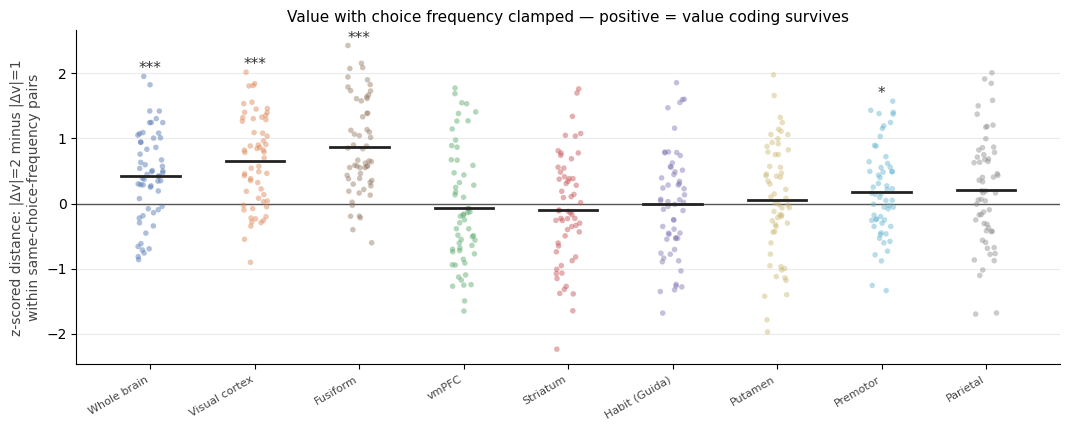

In [15]:
def _z(x):
    x = np.asarray(x, dtype=float)
    sd = x.std()
    return np.zeros_like(x) if sd == 0 else (x - x.mean()) / sd


def same_frequency_value_test(mask, scope="pooled"):
    """Per subject: mean(z-scored distance | |dvalue|=2) - mean(... | |dvalue|=1),
    restricted to non-figure pairs sharing the same choice-frequency label.
    Mirrors run_rsa_roi.value_contrast's mean-difference convention. Positive = value
    coding survives with choice frequency held exactly constant.
    """
    rdms = load_rdms(RSA_DIR, mask, scope)
    rows = []
    for sub, r in rdms.items():
        npz = model_rdms[sub]
        idx = np.flatnonzero(npz["non_figure"])
        sub_mat = r[np.ix_(idx, idx)]
        val, frq, cat = (npz["stim_value"][idx].astype(float),
                         npz["stim_frequency"][idx].astype(float), npz["stim_cat"][idx])
        n = len(idx)
        iu2 = np.triu_indices(n, 1)
        y = _z(sub_mat[iu2])
        dv = np.abs(val[:, None] - val[None, :])[iu2]
        same_f = np.abs(frq[:, None] - frq[None, :])[iu2] == 0
        cross = (cat[:, None] != cat[None, :])[iu2]

        def slope(mask_sel):
            hi, lo = y[mask_sel & (dv == 2)], y[mask_sel & (dv == 1)]
            return hi.mean() - lo.mean() if len(hi) and len(lo) else np.nan

        rows.append(dict(subject=sub, slope_all=slope(same_f),
                         slope_xcat=slope(same_f & cross),
                         n_xcat=int((same_f & cross).sum())))
    return pd.DataFrame(rows)


print("=== 8b. Value slope within same-choice-frequency pairs (|dv|=2 minus |dv|=1) ===")
print(f"{'mask':14s}{'all same-freq pairs (n=58)':>28s}{'cross-category only (n=16)':>30s}")
sf = {}
for mask in MASKS:
    r = same_frequency_value_test(mask)
    sf[mask] = r
    t_all, p_all = stats.ttest_1samp(r.slope_all.dropna(), 0)
    xcat = r[r.n_xcat == 6]   # subjects where all 6 same-freq pairs are cross-category
    if len(xcat) >= 3:
        t_x, p_x = stats.ttest_1samp(xcat.slope_xcat.dropna(), 0)
        xcat_str = f"{xcat.slope_xcat.mean():+.3f}{stars(p_x):<3s} (n={len(xcat)})"
    else:
        xcat_str = "n too small"
    print(f"{MASK_LABELS[mask]:14s}{r.slope_all.mean():>+18.3f}{stars(p_all):<3s}(n={len(r):2d})"
          f"{xcat_str:>30s}")

fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(MASKS)), 4.4))
for i, mask in enumerate(MASKS):
    v = sf[mask].slope_all.dropna().values
    t, p = stats.ttest_1samp(v, 0)
    ax.scatter(np.full(len(v), i) + np.random.uniform(-.12, .12, len(v)), v,
               s=16, color=COLORS[mask], alpha=.45, edgecolor="none", zorder=3)
    ax.plot([i - .28, i + .28], [v.mean()] * 2, color="#222222", linewidth=2, zorder=5)
    if stars(p):
        ax.text(i, v.max(), stars(p), ha="center", va="bottom", fontsize=11, color="#333333")
ax.axhline(0, color="#555555", linewidth=1, zorder=2)
ax.set_xticks(range(len(MASKS)))
ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=30, ha="right",
                   fontsize=8, color="#444444")
ax.set_ylabel("z-scored distance: |Δv|=2 minus |Δv|=1\nwithin same-choice-frequency pairs",
              color="#444444")
ax.set_title("Value with choice frequency clamped — positive = value coding survives",
             fontsize=11)
ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
plt.show()

## 8c. ⚠️ PRELIMINARY, UNVALIDATED — a value × frequency-context interaction

§8b's positive value effect within same-frequency pairs sits oddly next to finding 1's
null in the joint regression (`value + category + frequency`, all 15 non-figure pairs).
Two diagnostics run to reconcile them:

1. **Is finding 1's null just omitted-variable bias in reverse?** Drop frequency from the
   regression entirely (`category + value` only, all pairs). If frequency's positive
   effect (finding 2) is confounded with value (r=−0.35 by design), removing it should
   bias β(value) in the *positive* direction, matching §8b's sign.
2. **Does the value effect actually flip sign between same- and different-frequency
   pairs?** Split all 15 non-figure pairs into same-frequency (6) and different-frequency
   (9), compute the §8b-style slope in each, and test the difference.

**This entire section is exploratory, computed once, not yet checked against the
shuffled/blocked/remove-mean controls already on disk, and not yet subjected to any
multiple-comparison correction. Do not cite these numbers outside this notebook until
that validation pass has run — tracked as the top open thread below.**

=== 8c.1 beta_value: full model vs frequency dropped entirely ===
mask             full (cat+val+freq)  freq dropped (cat+val)
Whole brain               +0.034                  -0.036    
Visual cortex             -0.039                  -0.149*** 
Fusiform                  -0.022                  -0.143*** 
vmPFC                     -0.080*                 -0.070*   


Striatum                  +0.051                  +0.028    
Habit (Guida)             +0.042                  +0.024    
Putamen                   +0.028                  +0.010    
Premotor                  +0.030                  +0.014    
Parietal                  +0.045                  +0.016    
>>> if beta_value moves NEGATIVE when frequency is dropped (not positive/toward
>>> S8b's sign), the joint regression's null is not simple omitted-variable bias.

=== 8c.2 value slope (|dv|=2 minus |dv|=1): same- vs different-frequency pairs ===
mask            same-freq (n=6/subj)  diff-freq (n=9/subj)   interaction
Whole brain               +0.426***             -0.239*       +0.665*** 
Visual cortex             +0.651***             -0.579***     +1.230*** 
Fusiform                  +0.869***             -0.488***     +1.357*** 
vmPFC                     -0.067                -0.312**      +0.244    


Striatum                  -0.104                +0.230*       -0.334*   
Habit (Guida)             -0.006                +0.243*       -0.249    
Putamen                   +0.058                +0.147        -0.089    
Premotor                  +0.183*               -0.032        +0.215    
Parietal                  +0.201                -0.012        +0.213    


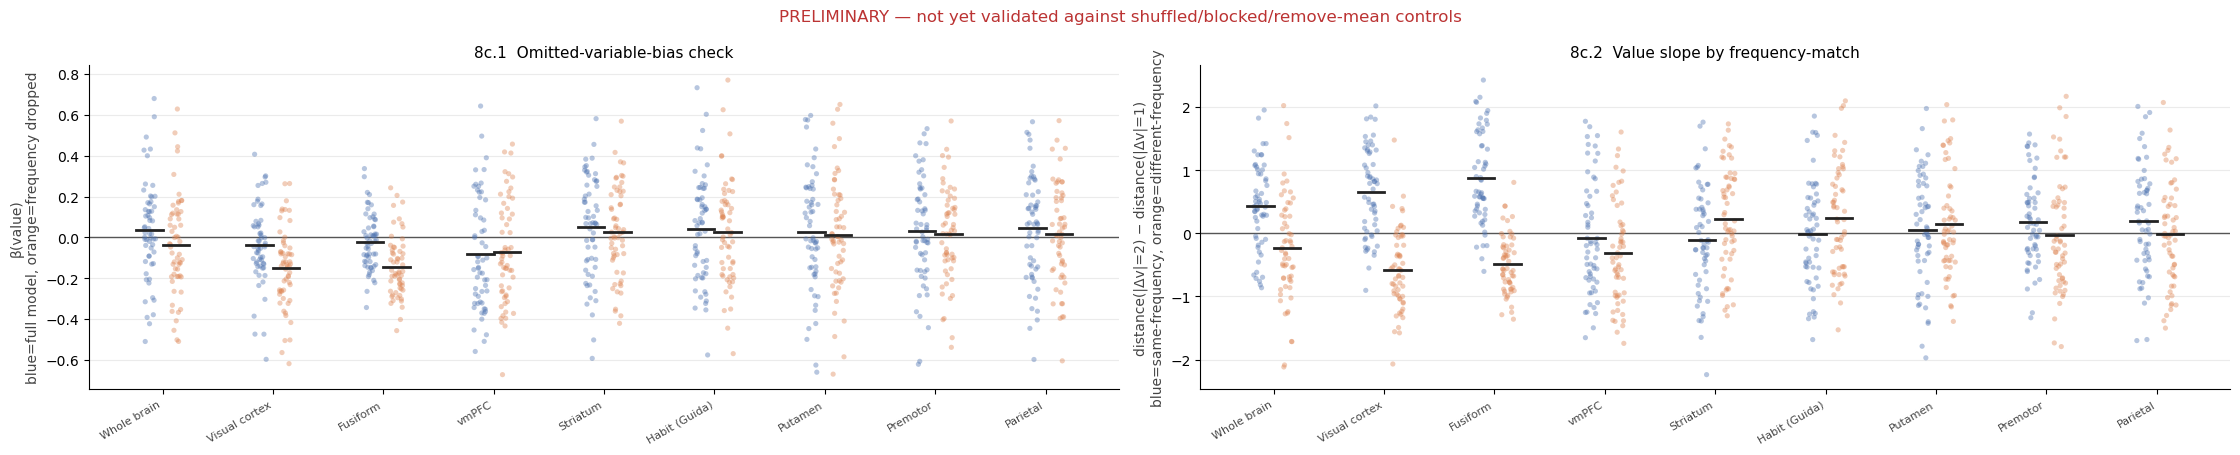

In [16]:
def fit_terms(rdm, model_rdms_dict, keep):
    """Minimal re-implementation of run_rsa_roi.fit_rdm_regression for ad-hoc term sets
    not covered by the saved results.csv (e.g. dropping a regressor entirely)."""
    sub = np.ix_(keep, keep)
    iu_k = np.triu_indices(keep.sum(), 1)
    y = _z(rdm[sub][iu_k])
    names, cols = [], []
    for name, m in model_rdms_dict.items():
        v = m[sub][iu_k]
        if np.ptp(v) > 0:
            names.append(name)
            cols.append(_z(v))
    if not names:
        return {}
    coef, *_ = np.linalg.lstsq(np.column_stack([np.ones_like(y)] + cols), y, rcond=None)
    return dict(zip(names, coef[1:]))


# --- (1) omitted-variable-bias check: beta_value with vs without frequency ----------
print("=== 8c.1 beta_value: full model vs frequency dropped entirely ===")
print(f"{'mask':14s}{'full (cat+val+freq)':>22s}{'freq dropped (cat+val)':>24s}")
ovb_rows = {mask: [] for mask in MASKS}
for mask in MASKS:
    rdms = load_rdms(RSA_DIR, mask, "pooled")
    full, dropped = [], []
    for sub, r in rdms.items():
        npz = model_rdms[sub]
        keep = npz["non_figure"]
        models_full = {"category": npz["category"], "value": npz["value"],
                       "frequency": npz["frequency"]}
        models_drop = {"category": npz["category"], "value": npz["value"]}
        full.append(fit_terms(r, models_full, keep).get("value", np.nan))
        dropped.append(fit_terms(r, models_drop, keep).get("value", np.nan))
    full, dropped = np.array(full), np.array(dropped)
    ovb_rows[mask] = (full, dropped)
    t1, p1 = stats.ttest_1samp(full[~np.isnan(full)], 0)
    t2, p2 = stats.ttest_1samp(dropped[~np.isnan(dropped)], 0)
    print(f"{MASK_LABELS[mask]:14s}{np.nanmean(full):>+18.3f}{stars(p1):<4s}"
          f"{np.nanmean(dropped):>+20.3f}{stars(p2):<4s}")
print(">>> if beta_value moves NEGATIVE when frequency is dropped (not positive/toward")
print(">>> S8b's sign), the joint regression's null is not simple omitted-variable bias.")

# --- (2) does the value slope flip sign between same- and different-frequency pairs? -
print("\n=== 8c.2 value slope (|dv|=2 minus |dv|=1): same- vs different-frequency pairs ===")
print(f"{'mask':14s}{'same-freq (n=6/subj)':>22s}{'diff-freq (n=9/subj)':>22s}{'interaction':>14s}")
interaction_rows = {}
for mask in MASKS:
    rdms = load_rdms(RSA_DIR, mask, "pooled")
    same_s, diff_s = [], []
    for sub, r in rdms.items():
        npz = model_rdms[sub]
        idx = np.flatnonzero(npz["non_figure"])
        sub_mat = r[np.ix_(idx, idx)]
        val, frq = npz["stim_value"][idx].astype(float), npz["stim_frequency"][idx].astype(float)
        iu2 = np.triu_indices(len(idx), 1)
        y = _z(sub_mat[iu2])
        dv = np.abs(val[:, None] - val[None, :])[iu2]
        same_f = np.abs(frq[:, None] - frq[None, :])[iu2] == 0

        def slope(sel):
            hi, lo = y[sel & (dv == 2)], y[sel & (dv == 1)]
            return hi.mean() - lo.mean() if len(hi) and len(lo) else np.nan

        same_s.append(slope(same_f))
        diff_s.append(slope(~same_f))
    same_s, diff_s = np.array(same_s), np.array(diff_s)
    interaction_rows[mask] = (same_s, diff_s)
    ok = ~np.isnan(same_s) & ~np.isnan(diff_s)
    t1, p1 = stats.ttest_1samp(same_s[ok], 0)
    t2, p2 = stats.ttest_1samp(diff_s[ok], 0)
    t3, p3 = stats.ttest_1samp(same_s[ok] - diff_s[ok], 0)
    print(f"{MASK_LABELS[mask]:14s}{np.nanmean(same_s):>+18.3f}{stars(p1):<4s}"
          f"{np.nanmean(diff_s):>+18.3f}{stars(p2):<4s}"
          f"{(np.nanmean(same_s)-np.nanmean(diff_s)):>+10.3f}{stars(p3):<4s}")

fig, axes = plt.subplots(1, 2, figsize=(max(13, 2.5 * len(MASKS)), 4.6))
for ax, (rows, title, ylab) in zip(axes, [
        (ovb_rows, "8c.1  Omitted-variable-bias check",
         "β(value)\nblue=full model, orange=frequency dropped"),
        (interaction_rows, "8c.2  Value slope by frequency-match",
         "distance(|Δv|=2) − distance(|Δv|=1)\nblue=same-frequency, orange=different-frequency")]):
    for i, mask in enumerate(MASKS):
        a, b = rows[mask]
        ok = ~np.isnan(a) & ~np.isnan(b)
        ax.scatter(np.full(ok.sum(), i - .12) + np.random.uniform(-.06, .06, ok.sum()),
                   a[ok], s=14, color="#4C72B0", alpha=.4, edgecolor="none", zorder=3)
        ax.scatter(np.full(ok.sum(), i + .12) + np.random.uniform(-.06, .06, ok.sum()),
                   b[ok], s=14, color="#DD8452", alpha=.4, edgecolor="none", zorder=3)
        ax.plot([i - .24, i], [np.nanmean(a)] * 2, color="#222222", linewidth=2, zorder=5)
        ax.plot([i, i + .24], [np.nanmean(b)] * 2, color="#222222", linewidth=2, zorder=5)
    ax.axhline(0, color="#555555", linewidth=1, zorder=2)
    ax.set_xticks(range(len(MASKS)))
    ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=30, ha="right",
                       fontsize=8, color="#444444")
    ax.set_ylabel(ylab, color="#444444")
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
fig.suptitle("PRELIMINARY — not yet validated against shuffled/blocked/remove-mean controls",
             fontsize=12, color="#B33")
fig.tight_layout()
plt.show()

## Findings

n=58 (all `participants_mvpa.tsv` subjects except `sub-46`, absent from the BBT — see
`run_rsa_roi.py --dry-run`), 2026-08-27. Cluster jobs: real/shuffled/remove-mean/blocked
(58/58 each, `model` ∈ {objective, rl, ck}). Pooled scope, non-figure subset,
`model='objective'` unless noted. **Terminology correction from earlier in the day:**
the "frequency" regressor is *choice* frequency, not presentation frequency — every
stimulus is shown equally often (§1b); the label encodes how often the subject *chose*
the stimulus, manipulated via pairing. Everywhere below that previously said "exposure"
or invoked repetition suppression has been corrected.

**1. The joint-regression null for value (β≈0, findings 1 as originally stated) does
not mean "no value coding" — §8c shows it is two opposite-signed effects averaging
out.** Value predicts distance **positively** within same-choice-frequency pairs
(wholebrain +0.426\*\*\*, visual cortex +0.651\*\*\*, fusiform +0.869\*\*\*, §8b) and
**negatively** within different-frequency pairs (−0.239\* to −0.579\*\*\*, §8c.2); the
interaction is large and highly significant (+0.665 to +1.357, all p<0.001,
wholebrain/visual/fusiform). This is not omitted-variable bias in the simple sense —
dropping frequency from the regression pushes β(value) *further negative*
(visual cortex −0.149\*\*\*, fusiform −0.143\*\*\*, §8c.1), the opposite of what bias
toward §8b's sign would predict. **⚠️ This entire result is preliminary — computed once,
not yet checked against the shuffled/blocked/remove-mean controls, no multiple-comparison
correction. See §8c and the top open thread.**

**2. Choice-frequency (the habit manipulation) is robustly represented — the best-
established result here.** β(frequency): wholebrain +0.220, visual cortex +0.351,
fusiform +0.378 (all p<0.001); striatum +0.077 (p=0.024, tentative — one of ~20
uncorrected comparisons). Shuffled control: all ~0. Survives the amplitude-confound
control (§7): grows slightly under `--remove-mean` (visual cortex +0.390, fusiform
+0.425, both p<0.001), and the direct amplitude~choice-frequency correlation is
negligible (visual cortex r=−0.066, p=0.004) — a weak signature exists but is far too
small to drive the RDM effect. This is pattern geometry, not a global-gain artifact.

**3. The raw same-value contrast (§4) is finding 2 leaking through — but see finding 1.**
Same-value pairs carry the maximal |Δchoice-frequency| = 2.0 by design (§1), so finding
2's effect mechanically drags this non-partialled contrast negative
(−0.202 to −0.637, p<0.011, wholebrain/visual/fusiform) regardless of any value effect.
Given finding 1, "trust the regression over this contrast" is no longer a clean
statement either — both need the §8c validation pass.

**4. Sanity check reproduces the design-checks prediction exactly.** On the full
8-stimulus set (§3, `subset='all'`), category/value/frequency are all strongly significant
and near-identical in magnitude (β≈0.15–0.28, p<0.001, wholebrain/visual/fusiform) —
because there they're all proxies for the same figure-vs-rest split. Confirms why the
non-figure subset is the one the other findings are read from.

**5. Learning dynamics: no clean value signal in any single run, and the apparent
test-run sign flip failed its robustness check — discarded.** β(value) stays near 0
across learning1→learning2→test in every ROI (§5). The same-value contrast is stably
negative in the learning runs across both split modes (fusiform −0.63/−0.59 interleaved,
−0.60/−0.53 blocked, both p<0.001), but the positive flip in `test` (fusiform +0.192,
p<0.01 interleaved) collapses under `--within-run-split blocked` (+0.074 ns) — the
low-SNR fragility `crossnobis_validation.ipynb` §4 predicted for per-run RDMs. Not
re-examined yet in light of finding 1; the per-run interaction is untested.

**6. Shuffled-label control is clean for everything checked so far** (§6): 5 masks × 4
terms, real vs. shuffled diverges only where findings 2–4 predict; shuffled shows ~2/20
nominal hits, consistent with uncorrected α=0.05 chance. **Not yet run on the §8c
interaction specifically** — that's the point of the validation pass below.

**7. The choice-kernel (`ck`) H-value regression is uninformative here, not
disconfirming.** `|ΔH|` gives a sign-flipped, worse-fitting result versus the design
label (§8a), but `|ΔH|` barely reconstructs the label's own pairwise structure
(corr(|Δlabel|,|ΔH|) ≈ 0, highly variable across subjects) despite per-stimulus H
correlating positively with the label (r≈+0.32). A median-split "H-bin" was tried as a
fix for the (hypothesized) magnitude-noise problem and doesn't help — same weak
reconstruction (~67% item-level agreement with the true label, but pairwise
reconstruction still ≈0) — so the noise is relational, not fixable by binning. Read §8a
as "this operationalisation of H doesn't work," not as evidence about habit strength.

### Open — in priority order
1. **Validate the §8c interaction before trusting it at all**: rerun the same-freq vs
   diff-freq value-slope comparison against `derivatives/rsa_shuffled` (should collapse
   to ~0 in both subsets if real), `derivatives/rsa_blocked` (learning-dynamics-style
   split reproducibility), and `derivatives/rsa_remove_mean`. FDR-correct across the ~20
   terms already in play plus the new interaction tests. This is squarely a "next
   session" item, not a quick addition — see `session-notes/` for the handoff.
2. If the interaction survives validation, finding 1/2/3's framing needs a full rewrite
   (this notebook's Findings section, the session note, and memory) — do not propagate
   "no value coding" as a conclusion elsewhere until then.
3. vmPFC β(value) (p≈0.03, stable across variants) and striatum β(frequency) (p≈0.02):
   both singles among many uncorrected comparisons even before §8c's additions.
4. §8a's H-value proxy: consider whether a better-fitting CK model (checked against
   behavioural log-likelihood) or a different summary than pooled-mean H would help,
   before concluding graded habit strength can't be tested this way at all.
5. Searchlight RSA out of scope unless the validated results warrant it.
6. Derivations: `derivatives/{rsa,rsa_shuffled,rsa_remove_mean,rsa_blocked}` on the
  cluster, synced to `dev_sample/bids_dataset/derivatives/` locally.